In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from matplotlib.patches import Polygon
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

from scipy import stats
from statsmodels.stats.multitest import multipletests
import seaborn as sns


import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.multitest import multipletests
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests
import seaborn as sns
import matplotlib.pyplot as plt

In [43]:
file_path_2B = "/Users/zkf/Desktop/test/file/test_predictions_all.csv"
file_path_2C = "/Users/zkf/Desktop/test/file/test_with_gaps_all.csv"

file_path_2E_1 = '/Users/zkf/Desktop/test/file/train_with_gaps_all.csv'
file_path_2E_2 = '/Users/zkf/Desktop/test/file/test_with_gaps_all.csv'

file_path_2F_1 = '/Users/zkf/Desktop/新项目/预处理后的原始数据/整个人群的患病数据包含协变量.csv'
file_path_2F_2 = '/Users/zkf/Desktop/test/file/test_with_gaps_all.csv'


file_path_2D_1 = '/Users/zkf/Desktop/test/file/train_with_gaps_all.csv'
file_path_2D_2 = '/Users/zkf/Desktop/test/file/test_with_gaps_all.csv'
file_path_2D_3 = "/Users/zkf/Desktop/新项目/预处理后的原始数据/data_clinical_indicators.csv"
file_path_2D_4 = "/Users/zkf/Desktop/新项目/预处理后的原始数据/最终人口学数据/demography.csv"




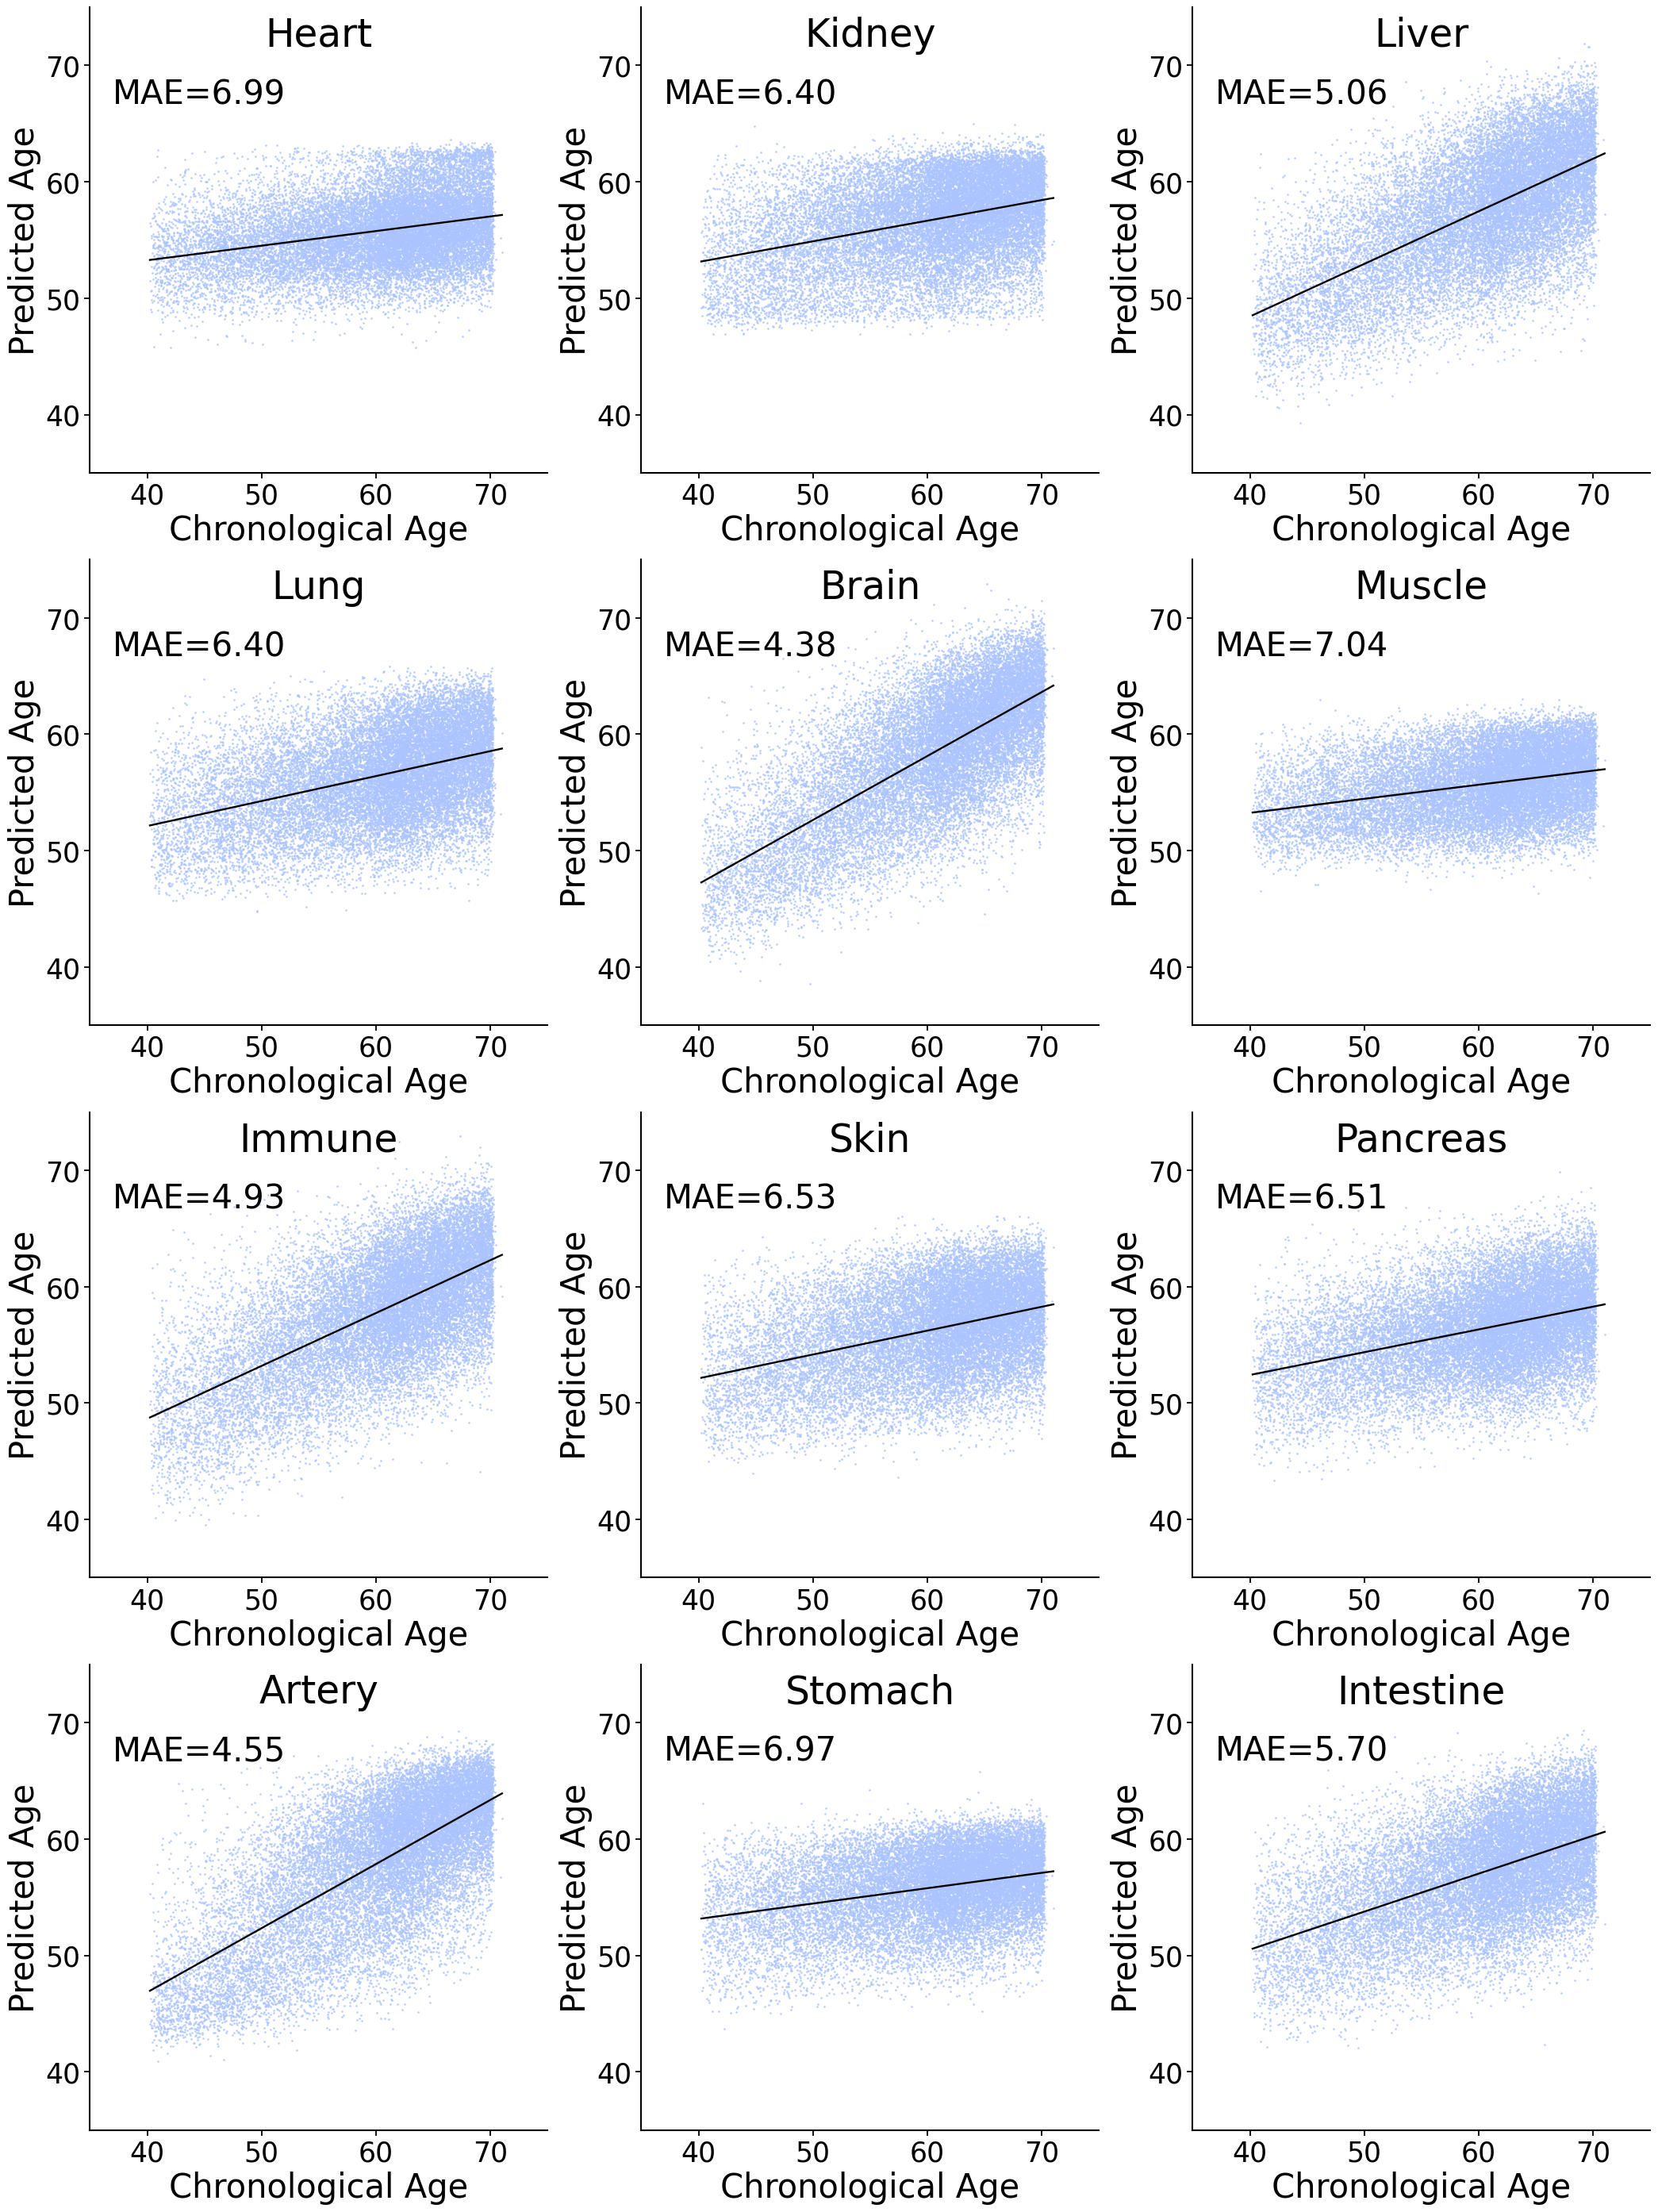

In [14]:
# Fig.2B
df = pd.read_csv(file_path_2B)

# 列名
age_col = "age_at_assessment"

ORGAN_AGE_COLS = [
    "Heart_Age", "Kidney_Age", "Liver_Age", "Lung_Age",
    "Brain_Age", "Muscle_Age", "Immune_Age", "Skin_Age",
    "Pancreas_Age", "Artery_Age", "Stomach_Age", "Intestine_Age"
]
organs = ORGAN_AGE_COLS


fig, axes = plt.subplots(4, 3, figsize=(21, 28))
axes = axes.flatten() 


# 自定义颜色
custom_color = '#abc4ff'

# 为每个器官绘制散点图
for i, organ in enumerate(organs):
    ax = axes[i]

    
    x_data = df[age_col]
    y_data = df[organ]

    
    mask = x_data.notna() & y_data.notna()
    x = x_data[mask]
    y = y_data[mask]

    
    mae = np.nan
    if len(x) > 0:
        mae = np.mean(np.abs(y - x))

    ax.scatter(x, y, c=custom_color, alpha=0.7, s=1)


    if len(x) >= 2:
        coeffs = np.polyfit(x, y, 1)
        poly1d_fn = np.poly1d(coeffs)
        x_line = np.linspace(x.min(), x.max(), 1000)
        y_line = poly1d_fn(x_line)
        ax.plot(x_line, y_line, 'k-', linewidth=1.7)

    
    display_name = organ.removesuffix("_Age")
    ax.text(0.5, 0.9, display_name, transform=ax.transAxes,
            fontsize=35, ha='center', va='bottom')

    # MAE文本
    if not np.isnan(mae):
        mae_text = f"MAE={mae:.2f}"
        ax.text(0.05, 0.85, mae_text, transform=ax.transAxes,
                fontsize=30, ha='left', va='top')

    
    ax.set_xlim(35, 75)
    ax.set_ylim(35, 75)


    ax.xaxis.set_major_locator(MultipleLocator(10))
    ax.yaxis.set_major_locator(MultipleLocator(10))

    ax.set_xlabel('Chronological Age', fontsize=30)
    ax.set_ylabel('Predicted Age', fontsize=30)

    ax.tick_params(axis='both', which='major', labelsize=25)

    
    for axis in ['bottom', 'left']:
        ax.spines[axis].set_linewidth(1.5)

    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    
    ax.tick_params(axis='both', which='major', width=1.3, length=5)
    ax.tick_params(axis='both', which='major', width=1.3, length=5)

plt.tight_layout()
plt.show()

[[1.         0.08813731 0.14107571 0.11171115 0.13593466 0.29113204
  0.14199813 0.05336195 0.14939416 0.19255856 0.11511005 0.09269404]
 [0.08813731 1.         0.13446988 0.11110346 0.16279651 0.04990354
  0.13247979 0.11221766 0.15276873 0.14822405 0.15466703 0.17230061]
 [0.14107571 0.13446988 1.         0.18250406 0.22034785 0.08790693
  0.2536534  0.20321395 0.24675919 0.34744117 0.15656524 0.18845916]
 [0.11171115 0.11110346 0.18250406 1.         0.18776359 0.02669157
  0.2620933  0.11638803 0.25620282 0.20205619 0.14744474 0.17104814]
 [0.13593466 0.16279651 0.22034785 0.18776359 1.         0.11860815
  0.21093381 0.14398843 0.17804762 0.27141893 0.16404003 0.16111953]
 [0.29113204 0.04990354 0.08790693 0.02669157 0.11860815 1.
  0.09393657 0.0112911  0.09785705 0.06857995 0.0420617  0.07824014]
 [0.14199813 0.13247979 0.2536534  0.2620933  0.21093381 0.09393657
  1.         0.16099444 0.22819916 0.2490567  0.17328214 0.22578473]
 [0.05336195 0.11221766 0.20321395 0.11638803 0.1

/var/folders/ll/3l49qks5171c56bp6lrdydjc0000gn/T/ipykernel_5585/4032121522.py:151: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


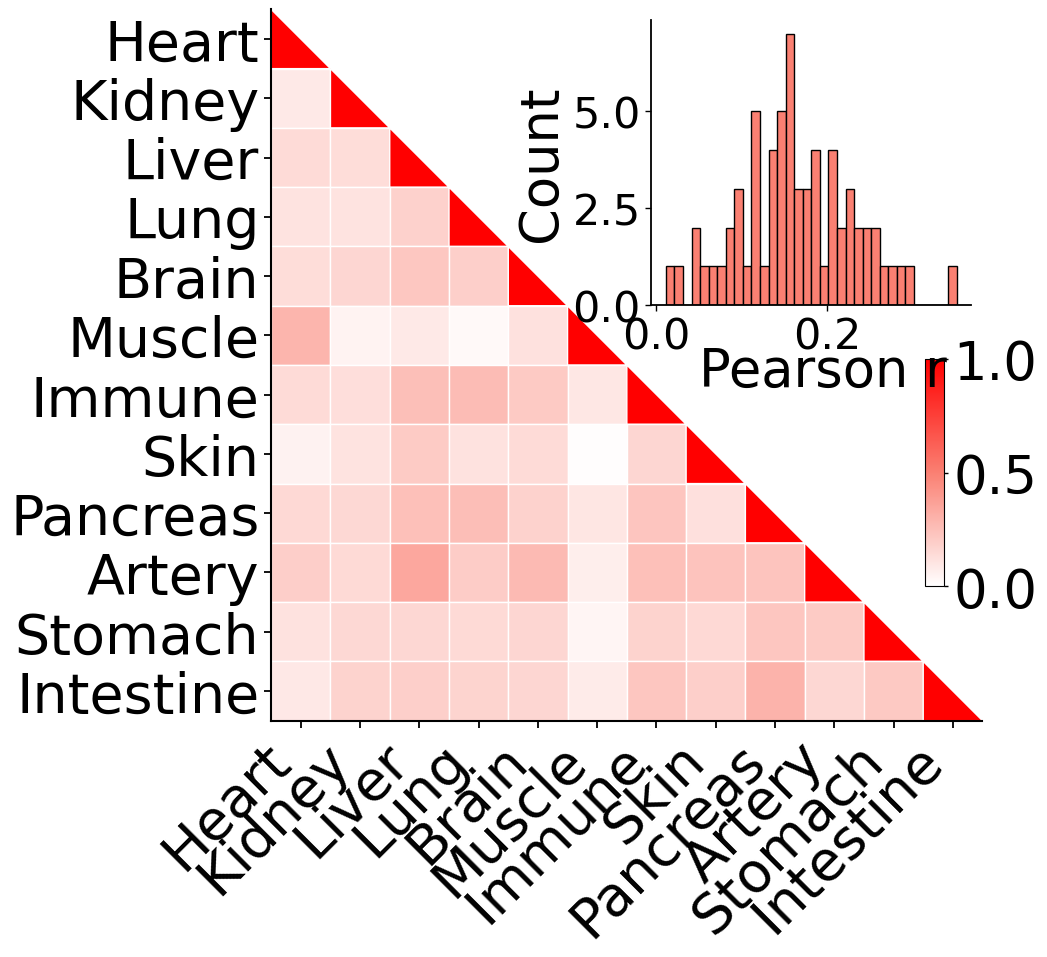

In [15]:
# Fig.2C


ORGAN_COLS = [
    "Heart_Z_Gap", "Kidney_Z_Gap", "Liver_Z_Gap", "Lung_Z_Gap",
    "Brain_Z_Gap", "Muscle_Z_Gap", "Immune_Z_Gap", "Skin_Z_Gap",
    "Pancreas_Z_Gap", "Artery_Z_Gap", "Stomach_Z_Gap", "Intestine_Z_Gap"
]

df = pd.read_csv(file_path_2C)[ORGAN_COLS]


df_complete = df.dropna(axis=0, how="any")

mat = df_complete.corr(method="pearson").to_numpy()
print(mat)
n = len(ORGAN_COLS)


labels = [c.replace("_Z_Gap", "") for c in ORGAN_COLS]


lower_mask = np.tril(np.ones((n, n), dtype=bool), k=0)
lower_vals = mat[lower_mask]
hist_vals = lower_vals[lower_vals < 1]  


cmap = LinearSegmentedColormap.from_list("w_salmon_red", ["white", "salmon", "red"])

norm = plt.Normalize(vmin=0, vmax=1)


fig, ax = plt.subplots(figsize=(10, 10))

ax.set_aspect("equal")


for i in range(n):         
    for j in range(n):     
        if i < j:
            continue

        val = mat[i, j]
        if np.isnan(val):
            continue

       
        y_bottom = n - i - 1
        x_left = j

        if i == j:
            poly_xy = np.array([
                [x_left,     y_bottom],
                [x_left,     y_bottom + 1],
                [x_left + 1, y_bottom]
            ])
        else:
            poly_xy = np.array([
                [x_left,     y_bottom],
                [x_left + 1, y_bottom],
                [x_left + 1, y_bottom + 1],
                [x_left,     y_bottom + 1]
            ])

        ax.add_patch(Polygon(
            poly_xy, closed=True,
            facecolor=cmap(norm(val)),
            edgecolor="white", linewidth=1.0
        ))


ax.set_xlim(0, n)
ax.set_ylim(0, n)


ax.tick_params(axis='both', which='major', width=1.3, length=5)

for axis in ['bottom', 'left']:
    ax.spines[axis].set_linewidth(1.5)


ax.set_xticks(np.arange(n) + 0.5)
ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=40)

ax.set_yticks(np.arange(n) + 0.5)
ax.set_yticklabels(list(reversed(labels)), fontsize=40)

ax.set_xlabel("")
ax.set_ylabel("")
ax.grid(False)


ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)


hist_ax = inset_axes(
    ax,
    width="45%",
    height="40%",
    loc="upper right",
    borderpad=0.8
)

bins = np.arange(np.nanmin(hist_vals), np.nanmax(hist_vals) + 0.01, 0.01)
hist_ax.hist(hist_vals, bins=bins, edgecolor="black", linewidth=1, color="salmon")
#hist_ax.set_title("Distribution", fontsize=18, pad=6)
hist_ax.set_ylabel("Count", fontsize=38)
hist_ax.set_xlabel("")
hist_ax.grid(False)


hist_ax.spines["top"].set_visible(False)
hist_ax.spines["right"].set_visible(False)
hist_ax.tick_params(axis="both", labelsize=31, width=1.0, length=4)

for axis in ['bottom', 'left']:
    hist_ax.spines[axis].set_linewidth(1.3)


cax = inset_axes(
    ax,
    width="6%",          
    height="80%",        
    loc="upper right",
    borderpad=0.8,
    bbox_to_anchor=(-0.05, -1.15, 1, 1),   
    bbox_transform=hist_ax.transAxes
)


mappable = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
mappable.set_array(lower_vals)  

cbar = fig.colorbar(mappable, cax=cax, orientation="vertical")
cbar.set_label("Pearson r", fontsize=38, labelpad=8, rotation=0)


min_val = np.nanmin(lower_vals)
max_val = np.nanmax(lower_vals)
print(f": {min_val:.3f} 到 {max_val:.3f}")


cbar.set_ticks([0, 0.5, 1.0])
cbar.set_ticklabels(['0.0', '0.5', '1.0'])

cbar.ax.yaxis.set_label_coords(-5.3, 1.06)
cbar.ax.tick_params(labelsize=38, width=1.0, length=3)


plt.tight_layout()


plt.show()


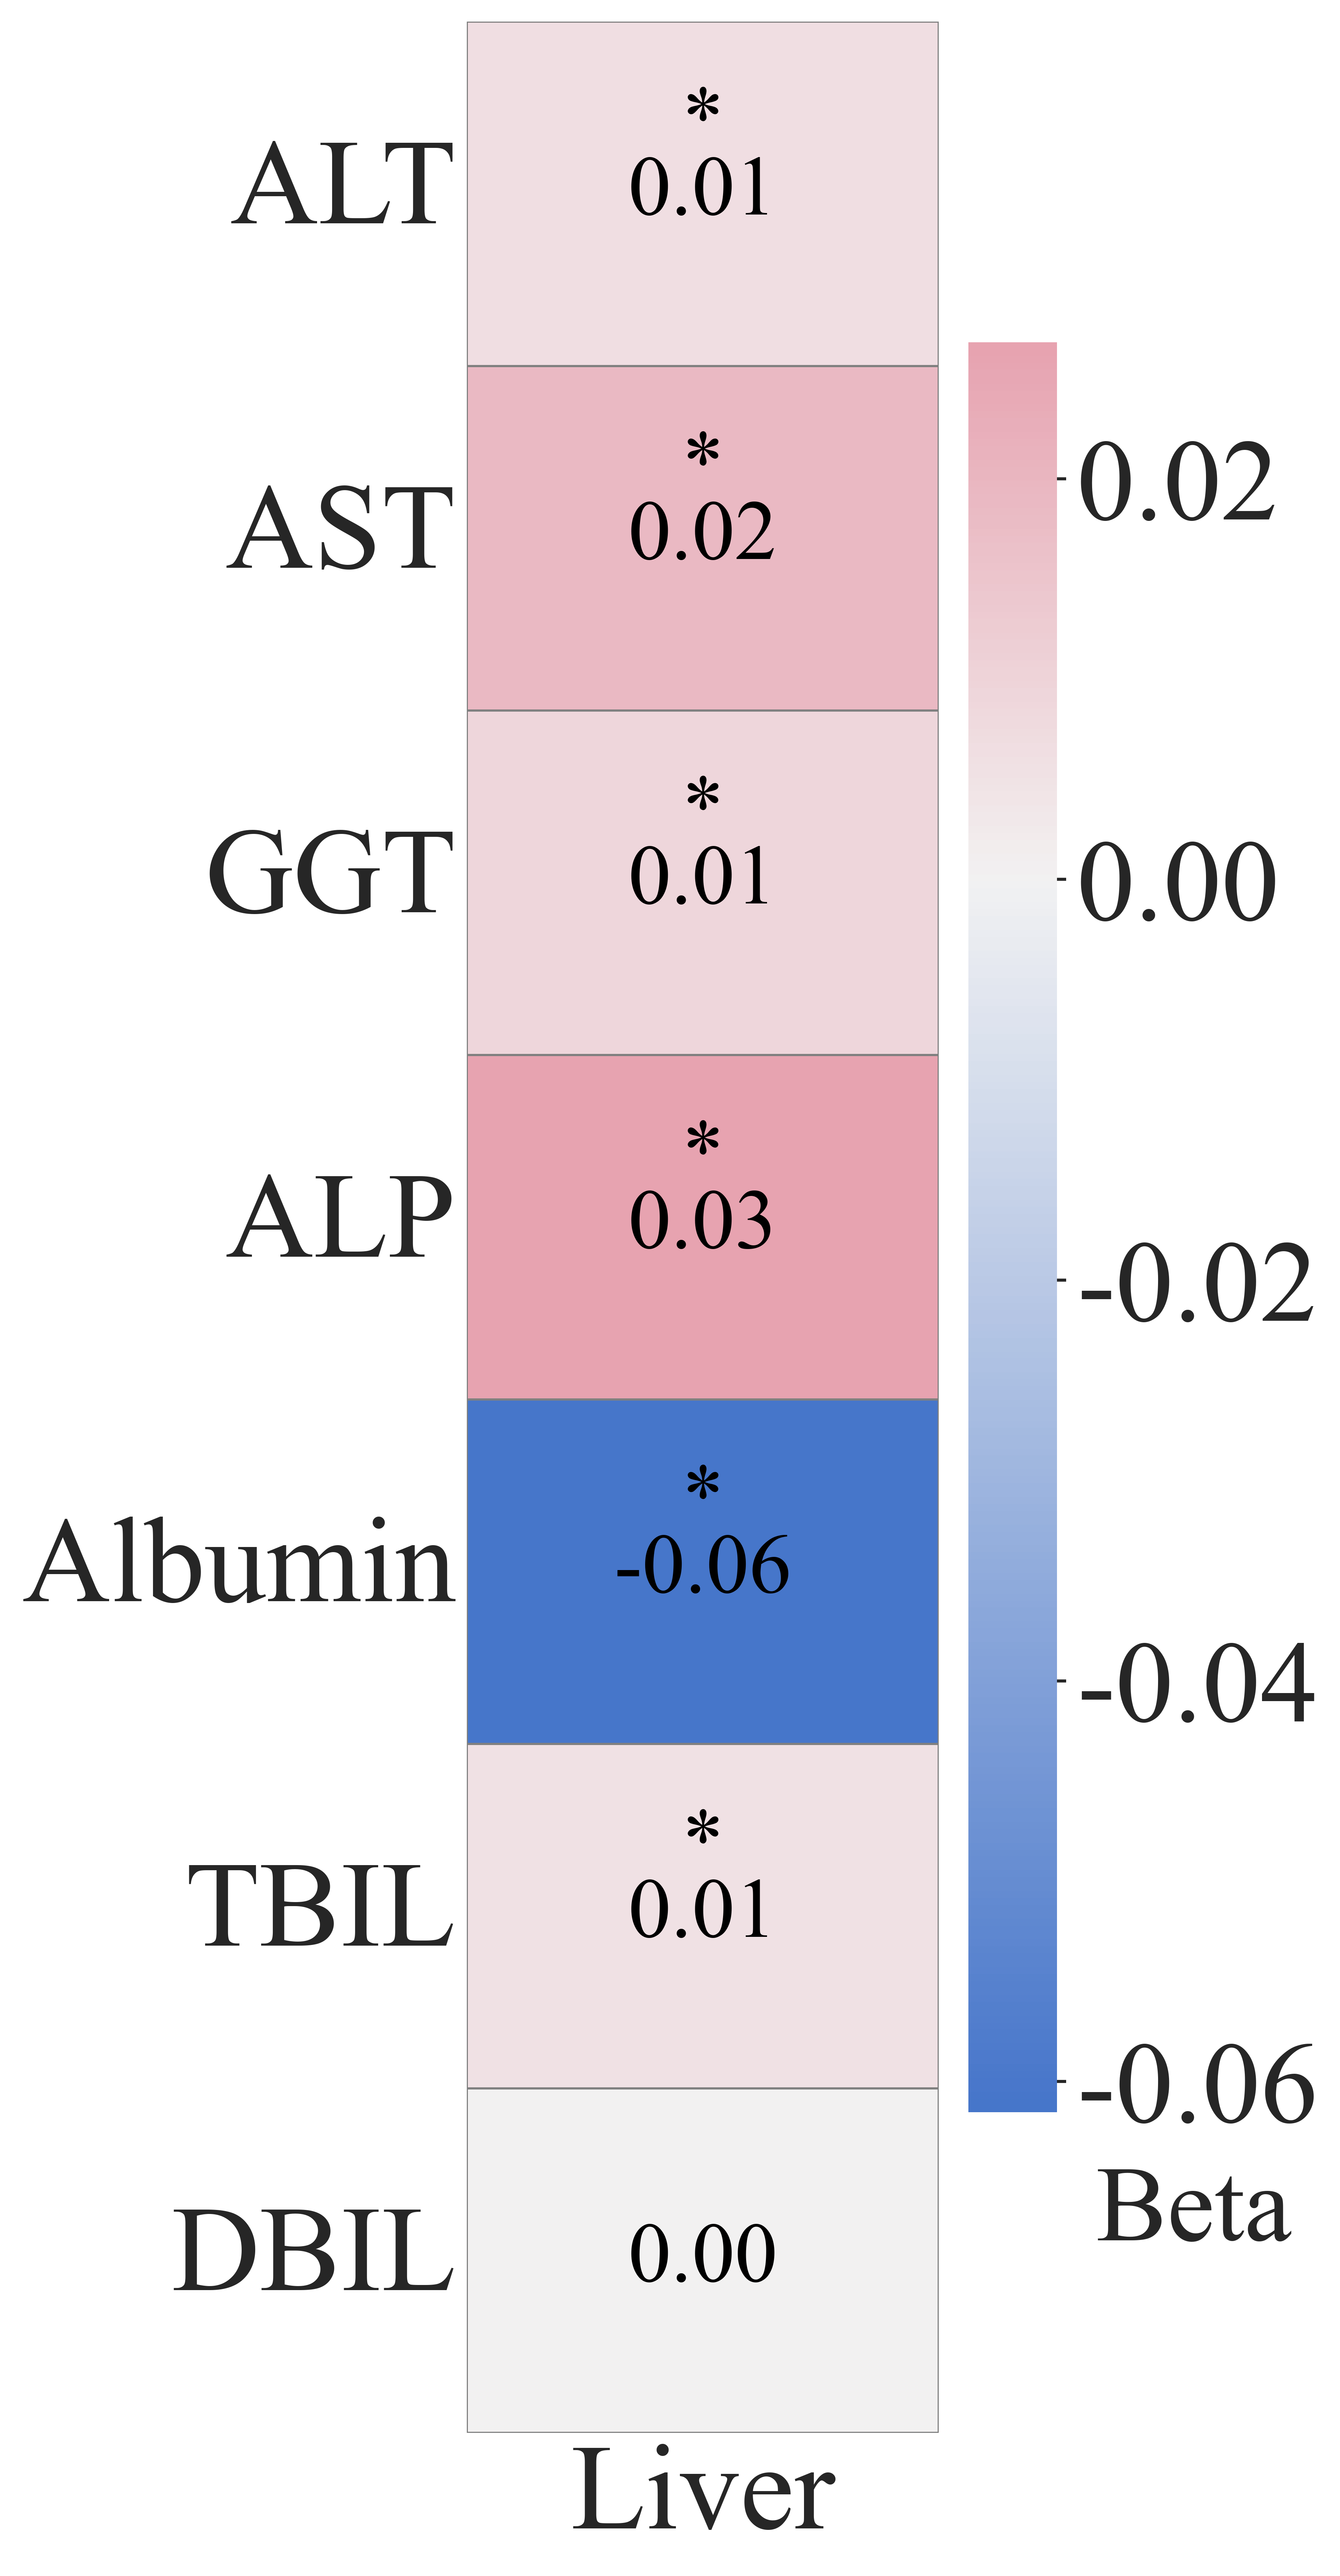

In [44]:
# Fig.2D


train_df = pd.read_csv(file_path_2D_1)
test_df = pd.read_csv(file_path_2D_2)
gap_df = pd.concat([train_df, test_df], axis=0).drop_duplicates(subset=['eid'])

clinical_df = pd.read_csv(file_path_2D_3)
demo_df = pd.read_csv(file_path_2D_4)

merged_df = pd.merge(gap_df[['eid', 'Liver_Z_Gap', 'age_at_assessment']], clinical_df, on='eid', how='inner')
merged_df = pd.merge(merged_df, demo_df[['eid', 'sex', 'bmi_calc']], on='eid', how='inner')

liver_indicators = ['alt', 'ast', 'ggt', 'alp', 'albumin', 'total_bil', 'direct_bil']
merged_df = merged_df.dropna(subset=['Liver_Z_Gap', 'age_at_assessment', 'sex', 'bmi_calc'] + liver_indicators).copy()

log_indicators = ['alt', 'ast', 'ggt', 'alp', 'total_bil', 'direct_bil']
for col in log_indicators:
    merged_df[f'log_{col}'] = np.log(merged_df[col] + 1)

merged_df['sex'] = merged_df['sex'].astype('category')

results_list = []
target_variables = {
    'alt': 'log_alt',
    'ast': 'log_ast',
    'ggt': 'log_ggt',
    'alp': 'log_alp',
    'albumin': 'albumin',
    'total_bil': 'log_total_bil',
    'direct_bil': 'log_direct_bil'
}

for original_name, model_target in target_variables.items():
    formula = f"{model_target} ~ Liver_Z_Gap + age_at_assessment + C(sex) + bmi_calc"
    model = smf.ols(formula, data=merged_df).fit()
    beta = model.params['Liver_Z_Gap']
    se = model.bse['Liver_Z_Gap']
    t_stat = model.tvalues['Liver_Z_Gap']
    p_val = model.pvalues['Liver_Z_Gap']
    results_list.append({
        'Indicator': original_name,
        'Beta': beta,
        'Std.Error': se,
        't-statistic': t_stat,
        'P-value': p_val
    })

summary_df = pd.DataFrame(results_list)
reject, p_adjusted, _, _ = multipletests(summary_df['P-value'], alpha=0.05, method='fdr_bh')
summary_df['FDR-adjusted P'] = p_adjusted

indicator_names = {
    'alt': 'ALT',
    'ast': 'AST',
    'ggt': 'GGT',
    'alp': 'ALP',
    'albumin': 'Albumin',
    'total_bil': 'TBIL',
    'direct_bil': 'DBIL'
}
summary_df['Indicator_Name'] = summary_df['Indicator'].map(indicator_names)
heatmap_data = summary_df.set_index('Indicator_Name')[['Beta']]
heatmap_data.columns = ['Liver']

custom_cmap = sns.diverging_palette(255, 5, as_cmap=True)
fig, ax = plt.subplots(figsize=(6, 12), dpi=600, facecolor='w')

sns.heatmap(
    heatmap_data,
    cmap=custom_cmap,
    annot=True,
    fmt=".2f",
    center=0,
    annot_kws={
        "size": 28,
        "weight": "normal",
        "color": "black",
        "va": "center",
        "ha": "center"
    },
    linewidths=0.5,
    linecolor='gray'
)

cbar = ax.collections[0].colorbar
cbar.ax.text(
    3.65, -0.03,
    'Beta',
    fontsize=35,
    ha='right',
    va='top',
    transform=cbar.ax.transAxes
)
cbar.ax.tick_params(labelsize=38, width=1.0, length=3)

for i, row in summary_df.iterrows():
    if row['FDR-adjusted P'] < 0.05:
        x = 0
        y = list(heatmap_data.index).index(row['Indicator_Name'])
        ax.text(x + 0.5, y + 0.3, '*', ha='center', va='center',
                color='black', fontsize=28)

ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=40)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, fontsize=40)
ax.tick_params(axis='y', which='both', length=0)
ax.tick_params(axis='x', which='both', length=0)
ax.set_ylabel('', fontsize=28)
ax.set_xlabel('', fontsize=28)

plt.tight_layout()
plt.show()

/var/folders/ll/3l49qks5171c56bp6lrdydjc0000gn/T/ipykernel_5585/3885716282.py:40: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  heatmap_data = df_heatmap.pivot_table(index='Organ', columns='Factor', values='Beta')


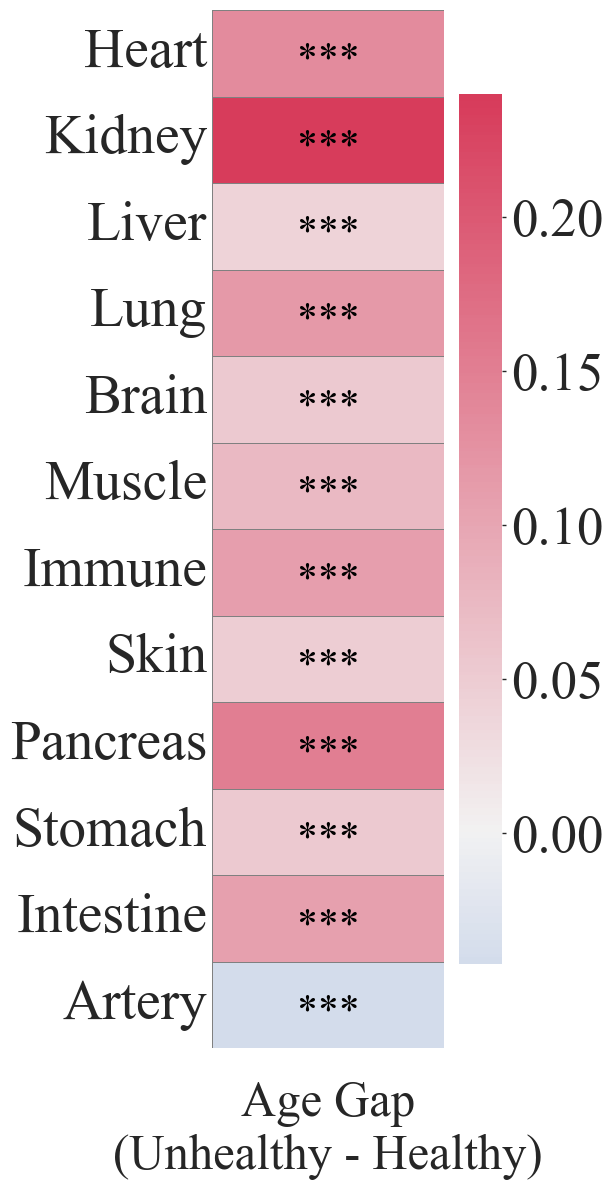

In [45]:
# Fig.2E

ORGAN_COLS = [
    "Heart_Z_Gap", "Kidney_Z_Gap", "Liver_Z_Gap", "Lung_Z_Gap",
    "Brain_Z_Gap", "Muscle_Z_Gap", "Immune_Z_Gap", "Skin_Z_Gap",
    "Pancreas_Z_Gap", "Stomach_Z_Gap", "Intestine_Z_Gap", "Artery_Z_Gap"
]

df_train = pd.read_csv(file_path_2E_1)
df_test = pd.read_csv(file_path_2E_2)

df_train = df_train[ORGAN_COLS].copy()
df_test = df_test[ORGAN_COLS].copy()

train_means = df_train.mean(axis=0)
test_means = df_test.mean(axis=0)
mean_diff = test_means - train_means

t_stat, p_values = stats.ttest_ind(df_test, df_train, axis=0)
_, p_adj, _, _ = multipletests(p_values, method='fdr_bh')

df_heatmap = pd.DataFrame({
    'Organ': ORGAN_COLS,
    'Factor': '',
    'Beta': mean_diff,
    'P_Adj': p_adj
})

df_heatmap['Organ'] = df_heatmap['Organ'].str.replace("_Z_Gap", "", regex=False)

desired_order = [
    "Heart", "Kidney", "Liver", "Lung",
    "Brain", "Muscle", "Immune", "Skin",
    "Pancreas", "Stomach", "Intestine", "Artery"
]

df_heatmap['Organ'] = pd.Categorical(df_heatmap['Organ'], categories=desired_order, ordered=True)
df_heatmap = df_heatmap.sort_values('Organ')

heatmap_data = df_heatmap.pivot_table(index='Organ', columns='Factor', values='Beta')
custom_cmap = sns.diverging_palette(255, 5, as_cmap=True)

fig, ax = plt.subplots(figsize=(6, 12))

sns.heatmap(
    heatmap_data,
    cmap=custom_cmap,
    center=0,
    annot=False,
    fmt=".2f",
    linewidths=0.5,
    linecolor='gray',
    annot_kws={
        "size": 28,
        "weight": "normal",
        "color": "black",
        "va": "center",
        "ha": "center"
    },
)

cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=38, width=1.0, length=3)

for i in range(len(df_heatmap)):
    organ = df_heatmap.iloc[i]['Organ']
    factor = df_heatmap.iloc[i]['Factor']
    p_adj = df_heatmap.iloc[i]['P_Adj']
    if 0.01 < p_adj < 0.05:
        x = heatmap_data.columns.get_loc(factor)
        y = heatmap_data.index.get_loc(organ)
        ax.text(x + 0.5, y + 0.5, '*', ha='center', va='center', color='black', fontsize=30)
    elif 0.001 < p_adj < 0.01:
        x = heatmap_data.columns.get_loc(factor)
        y = heatmap_data.index.get_loc(organ)
        ax.text(x + 0.5, y + 0.5, '**', ha='center', va='center', color='black', fontsize=30)
    elif p_adj < 0.001:
        x = heatmap_data.columns.get_loc(factor)
        y = heatmap_data.index.get_loc(organ)
        ax.text(x + 0.5, y + 0.6, '***', ha='center', va='center', color='black', fontsize=30)

ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=40)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, fontsize=40)

ax.xaxis.tick_bottom()
ax.xaxis.set_label_position('bottom')

ax.tick_params(axis='y', which='both', length=0)
ax.tick_params(axis='x', which='both', length=0)

ax.set_ylabel('', fontsize=40)
ax.set_xlabel('Age Gap\n(Unhealthy - Healthy)', fontsize=35, labelpad=20)

plt.tight_layout()
plt.show()

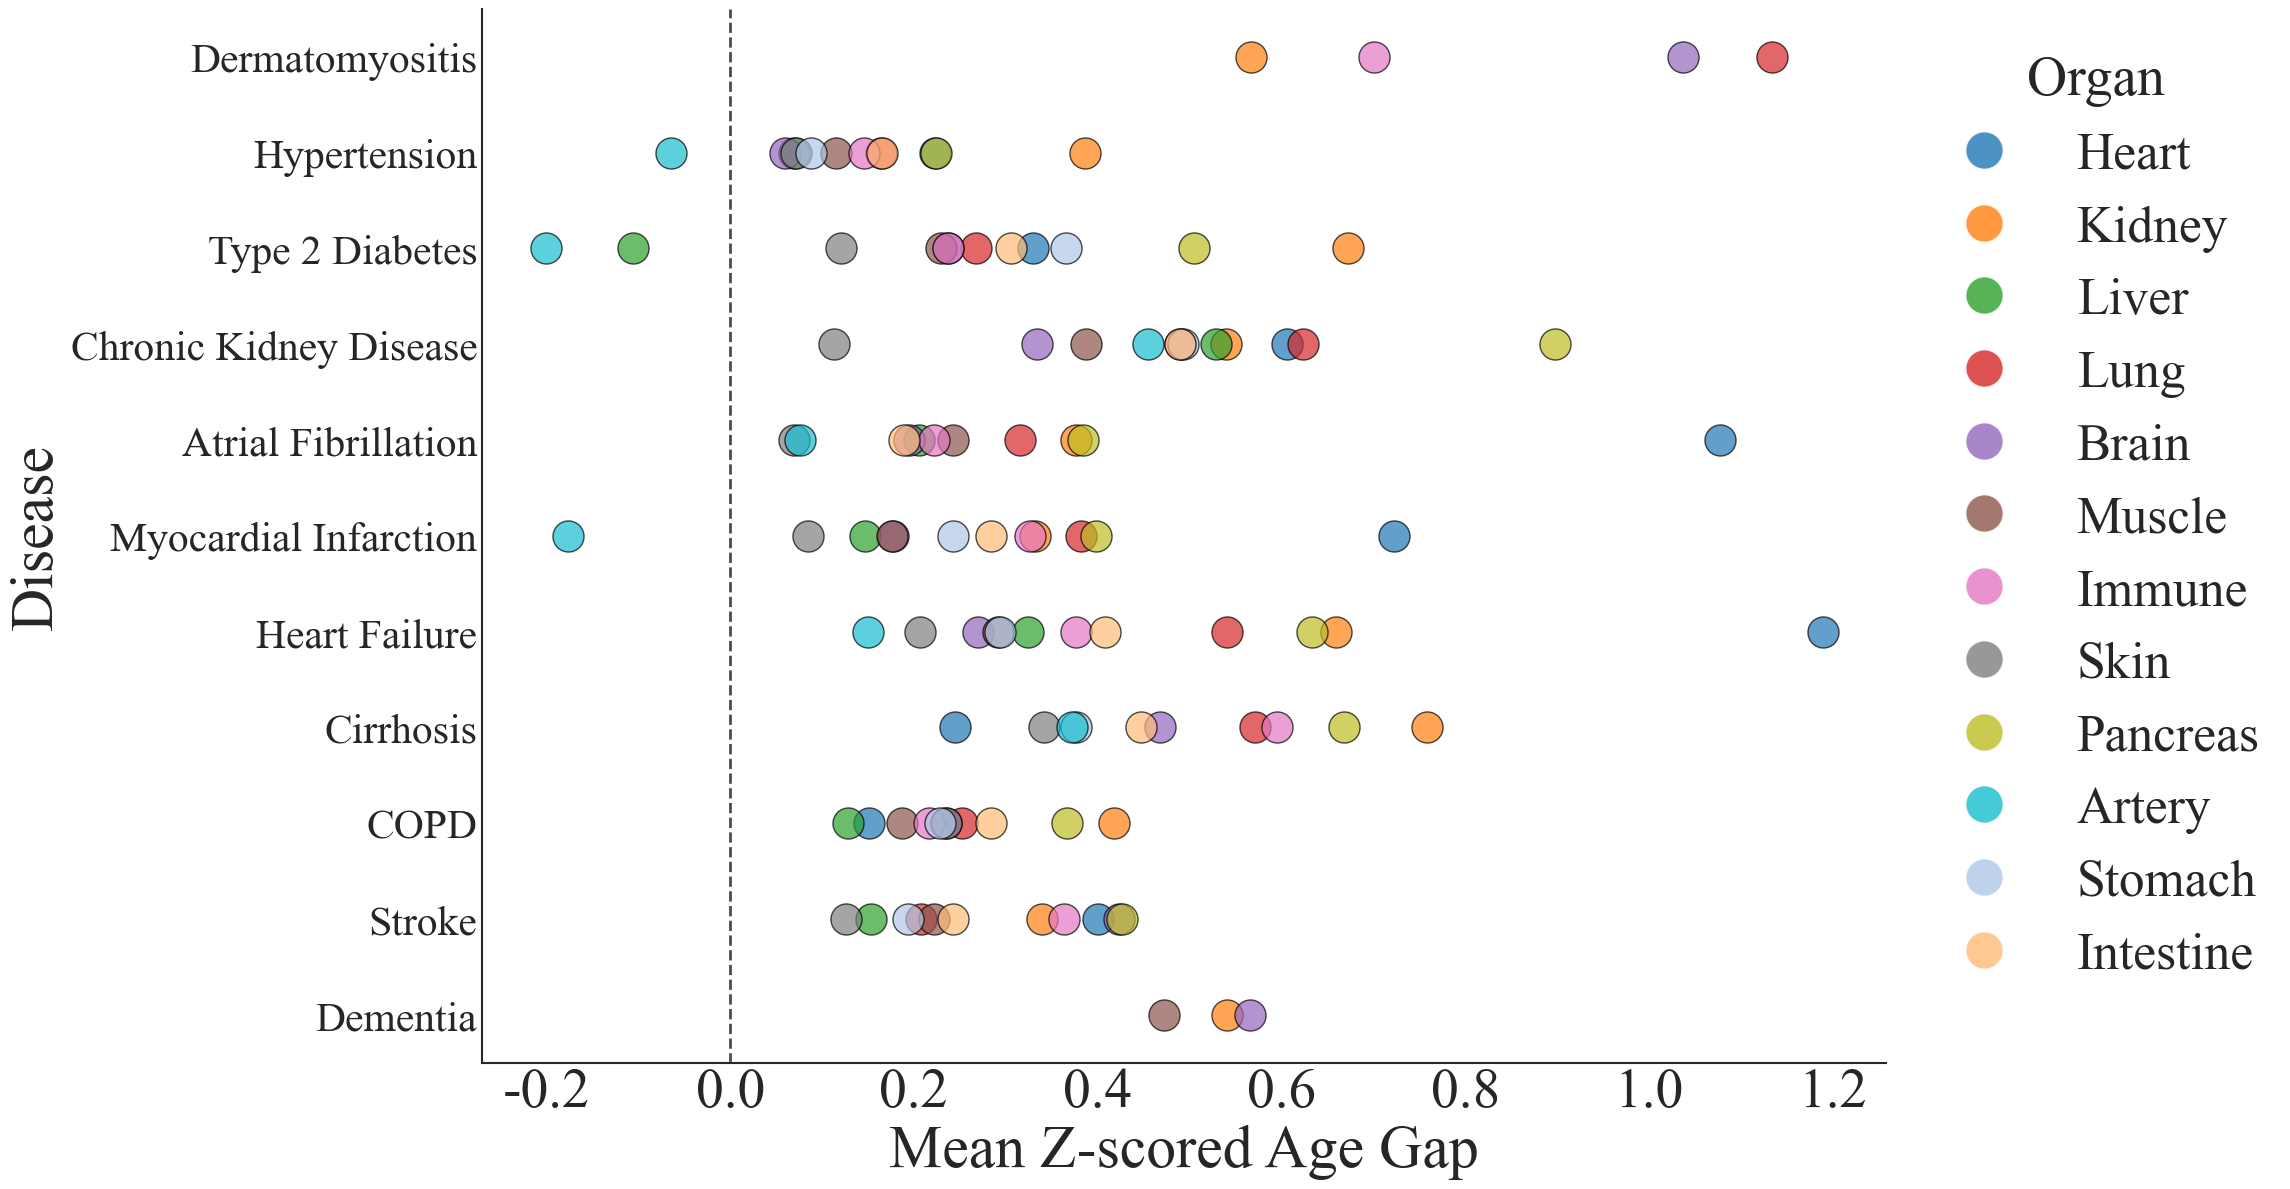

In [41]:
# Fig 2F

import pandas as pd
import numpy as np
from scipy import stats
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

disease_cols = [
    'date_dementia',
    'date_stroke', 'date_copd',
    'date_cirrhosis', 'date_hf', 'date_mi', 'date_af', 'date_ckd',
    'date_t2dm', 'date_hypertension', 'date_dermatomyositis'
]
disease_names_abbrev = [col.replace('date_', '') for col in disease_cols]

disease_names_full = {
    'dementia': 'Dementia',
    'stroke': 'Stroke',
    'copd': 'COPD',
    'cirrhosis': 'Cirrhosis',
    'hf': 'Heart Failure',
    'mi': 'Myocardial Infarction',
    'af': 'Atrial Fibrillation',
    'ckd': 'Chronic Kidney Disease',
    't2dm': 'Type 2 Diabetes',
    'hypertension': 'Hypertension',
    'dermatomyositis': 'Dermatomyositis'
}

ORGAN_ORDER = [
    "Heart_Z_Gap", "Kidney_Z_Gap", "Liver_Z_Gap", "Lung_Z_Gap",
    "Brain_Z_Gap", "Muscle_Z_Gap", "Immune_Z_Gap", "Skin_Z_Gap",
    "Pancreas_Z_Gap", "Stomach_Z_Gap", "Intestine_Z_Gap", "Artery_Z_Gap"
]
organ_names = [organ.replace('_Z_Gap', '') for organ in ORGAN_ORDER]

ALPHA = 0.05

df_disease = pd.read_csv(file_path_2F_1, usecols=['eid', 'assess_date'] + disease_cols)
df_disease['eid'] = df_disease['eid'].astype(str)

df_disease['assess_date'] = pd.to_datetime(df_disease['assess_date'], errors='coerce')
for col in disease_cols:
    df_disease[col] = pd.to_datetime(df_disease[col], errors='coerce')

df_gap = pd.read_csv(file_path_2E_2)
df_gap['eid'] = df_gap['eid'].astype(str)

df_merged = pd.merge(df_disease, df_gap, on='eid', how='inner')

result_mean = pd.DataFrame(index=organ_names, columns=disease_names_abbrev)
result_p = pd.DataFrame(np.nan, index=organ_names, columns=disease_names_abbrev)

all_p_values = []
all_indices = []

for disease_col, disease_name in zip(disease_cols, disease_names_abbrev):
    mask = (df_merged[disease_col].notna()) & (df_merged[disease_col] <= df_merged['assess_date'])
    df_diseased = df_merged[mask]

    if len(df_diseased) > 0:
        for organ_col, organ_name in zip(ORGAN_ORDER, organ_names):
            gap_values = df_diseased[organ_col].dropna()
            if len(gap_values) >= 3:
                t_stat, p_value = stats.ttest_1samp(gap_values, popmean=0)
                result_mean.loc[organ_name, disease_name] = gap_values.mean()
                result_p.loc[organ_name, disease_name] = p_value
                all_p_values.append(p_value)
                all_indices.append((organ_name, disease_name))
            else:
                result_mean.loc[organ_name, disease_name] = np.nan
                result_p.loc[organ_name, disease_name] = np.nan
    else:
        result_mean.loc[:, disease_name] = np.nan
        result_p.loc[:, disease_name] = np.nan

if all_p_values:
    reject, p_adj, _, _ = multipletests(all_p_values, alpha=ALPHA, method='fdr_bh')
    result_p_adj = result_p.copy()
    for i, (organ_name, disease_name) in enumerate(all_indices):
        result_p_adj.loc[organ_name, disease_name] = p_adj[i]
    result_significant = result_p_adj < ALPHA
else:
    result_significant = pd.DataFrame(False, index=organ_names, columns=disease_names_abbrev)

result_mean = result_mean.round(4)
TOTAL_TESTS = len(all_p_values) if all_p_values else 0

organ_colors = {
    'Heart': '#1f77b4', 'Kidney': '#ff7f0e', 'Liver': '#2ca02c', 'Lung': '#d62728',
    'Brain': '#9467bd', 'Muscle': '#8c564b', 'Immune': '#e377c2', 'Skin': '#7f7f7f',
    'Pancreas': '#bcbd22', 'Artery': '#17becf', 'Stomach': '#aec7e8', 'Intestine': '#ffbb78'
}

fig, ax = plt.subplots(figsize=(23, 12))

diseases = result_mean.columns.tolist()
organs = result_mean.index.tolist()

disease_labels = [disease_names_full.get(d, d) for d in diseases]

for i, disease in enumerate(diseases):
    gap_values = result_mean[disease].values
    is_significant = result_significant[disease].values
    for j, organ in enumerate(organs):
        if pd.notna(gap_values[j]) and is_significant[j]:
            ax.scatter(x=gap_values[j], y=i, color=organ_colors[organ], s=500, alpha=0.7, edgecolors='black', linewidth=1)

ax.set_yticks(range(len(diseases)))
ax.set_yticklabels(disease_labels, fontsize=30)
ax.tick_params(axis='x', labelsize=40)
ax.set_xlabel('Mean Z-scored Age Gap', fontsize=43)
ax.set_ylabel('Disease', fontsize=43)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='both', which='major', width=1.3, length=1.5, direction='in')
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)
ax.axvline(x=0, color='black', linestyle='--', linewidth=2, alpha=0.7)

legend_patches = [Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=27, alpha=0.8, label=organ) for organ, color in organ_colors.items()]
legend = ax.legend(handles=legend_patches, title='Organ', title_fontsize=40, fontsize=37, bbox_to_anchor=(1, 1), loc='upper left', frameon=False)

plt.tight_layout()
plt.show()

In [47]:
# Fig.2G


sns.set_style("white")

palette = {
    'Male': '#9ac1f0',
    'Female': '#faaac7'
}

df_train = pd.read_csv(file_path_2D_1)
df_test = pd.read_csv(file_path_2D_2)
df = pd.concat([df_train, df_test], axis=0, ignore_index=True)

ORGAN_GAPS = [
    'eid',
    "Skin_Z_Gap",
    "Liver_Z_Gap",
    "Brain_Z_Gap"
]
df = df[ORGAN_GAPS].copy()

df_demo = pd.read_csv(
    DEMO_FILE,
    usecols=['eid', 'sex']
)
df = pd.merge(df, df_demo, on='eid', how='inner')

organ_vars = [
    "Skin_Z_Gap",
    "Liver_Z_Gap",
    "Brain_Z_Gap"
]
df_melted = df.melt(
    id_vars=['eid', 'sex'],
    value_vars=organ_vars,
    var_name='organ',
    value_name='gap'
)
df_melted['organ'] = df_melted['organ'].str.replace('_Z_Gap', '', regex=False)

organ_order = ['Skin', 'Liver', 'Brain']
sex_order = ['Male', 'Female']
plot_df = df_melted.dropna(subset=['sex', 'organ', 'gap']).copy()
plot_df = plot_df[
    plot_df['organ'].isin(organ_order) &
    plot_df['sex'].isin(sex_order)
].copy()

def p_to_stars(p):
    if p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    else:
        return 'ns'

def add_significance_line(ax, x1, x2, y, h, text, lw=1.5, fs=34):
    ax.plot(
        [x1, x1, x2, x2],
        [y, y + h, y + h, y],
        lw=lw,
        c='k'
    )
    ax.text(
        (x1 + x2) * 0.5,
        y + h,
        text,
        ha='center',
        va='bottom',
        color='k',
        fontsize=fs
    )

fig, ax = plt.subplots(
    figsize=(16, 12),
    dpi=600,
    facecolor='w'
)

sns.boxplot(
    data=plot_df,
    x='organ',
    y='gap',
    hue='sex',
    order=organ_order,
    hue_order=sex_order,
    palette=palette,
    showfliers=False,
    width=0.65,
    ax=ax,
    boxprops=dict(edgecolor='k', linewidth=1.5),
    whiskerprops=dict(color='k', linewidth=1.5),
    capprops=dict(color='k', linewidth=1.5),
    medianprops=dict(color='k', linewidth=1.5)
)

stat_results = []
y_min, y_max = ax.get_ylim()
y_range = y_max - y_min
if y_range == 0:
    y_range = 1
box_width = 0.65
offset = box_width / 4
max_annotation_y = y_max

for i, organ in enumerate(organ_order):
    sub_df = plot_df[plot_df['organ'] == organ].copy()
    male_gap = sub_df.loc[sub_df['sex'] == 'Male', 'gap'].dropna()
    female_gap = sub_df.loc[sub_df['sex'] == 'Female', 'gap'].dropna()
    if len(male_gap) > 1 and len(female_gap) > 1:
        t_stat, p_value = stats.ttest_ind(
            male_gap,
            female_gap,
            equal_var=False
        )
        stat_results.append({
            'organ': organ,
            'index': i,
            'Male_N': len(male_gap),
            'Female_N': len(female_gap),
            'Male_mean': male_gap.mean(),
            'Female_mean': female_gap.mean(),
            'Male_std': male_gap.std(),
            'Female_std': female_gap.std(),
            't_stat': t_stat,
            'p_value': p_value,
            'sub_df': sub_df
        })
    else:
        stat_results.append({
            'organ': organ,
            'index': i,
            'Male_N': len(male_gap),
            'Female_N': len(female_gap),
            'Male_mean': male_gap.mean() if len(male_gap) > 0 else np.nan,
            'Female_mean': female_gap.mean() if len(female_gap) > 0 else np.nan,
            'Male_std': male_gap.std() if len(male_gap) > 0 else np.nan,
            'Female_std': female_gap.std() if len(female_gap) > 0 else np.nan,
            't_stat': np.nan,
            'p_value': np.nan,
            'sub_df': None
        })

valid_results = [r for r in stat_results if not np.isnan(r['p_value'])]
p_values = [r['p_value'] for r in valid_results]
if len(p_values) > 0:
    reject, p_corrected, _, _ = multipletests(
        p_values,
        alpha=0.05,
        method='fdr_bh'
    )
    for i, result in enumerate(valid_results):
        result['p_value_corrected'] = p_corrected[i]
        result['reject'] = reject[i]
        result['significance'] = p_to_stars(p_corrected[i])

for result in stat_results:
    if 'significance' not in result:
        result['significance'] = 'NA'
        result['p_value_corrected'] = np.nan
        result['reject'] = False

for result in stat_results:
    if result['sub_df'] is None or np.isnan(result['p_value']):
        continue
    organ = result['organ']
    i = result['index']
    sub_df = result['sub_df']
    p_corrected = result['p_value_corrected']
    stars = result['significance']
    organ_y_max = np.nanpercentile(sub_df['gap'], 99)
    y = organ_y_max + y_range * 0.06
    h = y_range * 0.035
    x1 = i - offset
    x2 = i + offset
    add_significance_line(
        ax=ax,
        x1=x1,
        x2=x2,
        y=y+0.58,
        h=h-0.02,
        text=stars,
        lw=1.5,
        fs=34
    )
    max_annotation_y = max(max_annotation_y, y + h)

ax.set_ylim(
    y_min,
    max_annotation_y + y_range * 0.12
)

ax.set_xlabel('', fontsize=43)
ax.set_ylabel('Organ Age Gap', fontsize=43)
ax.set_xticklabels(organ_order, fontsize=40)
ax.tick_params(
    axis='both',
    which='major',
    width=1.3,
    length=5,
    labelsize=40
)
for axis in ['bottom', 'left']:
    ax.spines[axis].set_linewidth(1.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(
    axis='y',
    ls='--',
    c='gray',
    alpha=0.7
)
ax.set_axisbelow(True)

legend_elements = [
    Rectangle((0, 0), 1, 1, facecolor=palette['Male'], edgecolor='k', linewidth=1.5),
    Rectangle((0, 0), 1, 1, facecolor=palette['Female'], edgecolor='k', linewidth=1.5)
]
ax.legend(
    handles=legend_elements,
    labels=['Male', 'Female'],
    frameon=False,
    fontsize=39,
    bbox_to_anchor=(0.68, 0.83),
    handletextpad=0.2,
    handlelength=0.8,
    handleheight=0.8
)
plt.tight_layout()
plt.show()

/var/folders/ll/3l49qks5171c56bp6lrdydjc0000gn/T/ipykernel_5585/720071181.py:198: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(organ_order, fontsize=40)
